# 下载遥感数据

## 介绍

本教程是实践性的：您将从Python中搜索云存档、下载卫星图像和检索矢量数据集。

免费可用的地球观测数据急剧增加。NASA、USGS和ESA提供PB级的图像，而云平台如[Microsoft Planetary Computer](https://planetarycomputer.microsoft.com)和[Google Earth Engine](https://earthengine.google.com)托管了这些档案的大部分，并提供符合STAC标准的API以供程序化访问。挑战不再是数据可用性，而是知道如何找到、过滤和获取您的确切需求。

选择合适的图像需要平衡空间分辨率、时间覆盖范围、云量和光谱波段。在本教程结束时，您将拥有一个可重复的Python工作流程，用于获取任何感兴趣区域的图像和矢量数据。

## 学习目标

在本教程结束时，您将能够：

- 识别主要的免费卫星图像计划及其关键特征
- 解释STAC规范及其四个核心组件（Catalog、Collection、Item、Asset）
- 使用STAC API和Planetary Computer搜索卫星图像
- 使用`geoai`包下载边界框内的NAIP航空图像
- 下载并合并Sentinel-2和Landsat波段为多波段GeoTIFF
- 从Overture Maps检索建筑轮廓等矢量数据集
- 按照GeoAI项目的最佳实践组织下载的数据

## 卫星图像来源

### NAIP（国家农业图像计划）

[国家农业图像计划（NAIP）](https://naip-usdaonline.hub.arcgis.com/)在农业生长季节获取美国大陆的航空图像。

- **空间分辨率**：约0.6米（60厘米）
- **光谱波段**：4个波段（红、绿、蓝和近红外）
- **覆盖范围**：美国大陆
- **重访周期**：每2至3年，取决于州
- **存档**：从2003年至今的图像可用。2009年前的图像仅为RGB。

NAIP的亚米级分辨率使其非常适合建筑轮廓提取、树冠映射和城市土地覆盖分类。

### Sentinel-2

[Sentinel-2](https://dataspace.copernicus.eu/data-collections/copernicus-sentinel-missions/sentinel-2)任务由ESA运营，目前包括Sentinel-2A、Sentinel-2B和Sentinel-2C，提供全球覆盖，重访时间约为5天。

- **空间分辨率**：10米（可见光和近红外）、20米（红边和短波红外）、60米（大气）
- **光谱波段**：13个波段，涵盖可见光到短波红外
- **覆盖范围**：北纬84度至南纬56度之间的全球陆地表面
- **存档**：从2015年至今的图像可用

Sentinel-2的高重访频率、全球覆盖和10米分辨率使其成为许多GeoAI应用的主力军。

### Landsat

[Landsat计划](https://www.usgs.gov/landsat-missions)是NASA和USGS的联合项目，是运行时间最长的民用地球观测计划，自1972年以来持续提供数据。

- **空间分辨率**：30米（多光谱）、15米（全色）、100米（热红外）
- **光谱波段**：11个波段，包括可见光、近红外、短波红外和热红外
- **覆盖范围**：全球
- **重访周期**：每颗卫星16天（组合后8天）
- **存档**：超过50年的连续图像

Landsat无与伦比的时间深度使其成为城市扩张、森林砍伐或冰川退缩等长期变化分析的必需品。

### 商业图像

多家商业提供商提供高分辨率图像（0.3-0.5米），具有快速任务能力。主要提供商包括Vantor（前身为Maxar）、Planet（每天全球覆盖，分辨率3-5米）和Airbus（Pleiades和SPOT）。这些数据集通常需要付费许可，但有些子集可免费用于研究。

### Vantor开放数据计划

[Vantor开放数据计划](https://vantor.com/company/open-data-program)根据CC-BY-NC-4.0许可证免费提供重大自然灾害前后捕获的高分辨率卫星图像。

数据作为STAC目录发布在AWS S3上，每个灾害事件作为单独的集合，包含事件前和事件后的COG。您可以使用[STAC Browser](https://radiantearth.github.io/stac-browser/#/external/vantor-opendata.s3.amazonaws.com/events/catalog.json)或[交互式Web应用](https://opengeos.org/maplibre-gl-vantor)浏览目录。

## 安装

取消注释以下行以安装所需的包。

In [1]:
# %pip install "geoai-py[extra]"

## 使用STAC搜索

### 什么是STAC？

[时空资产目录（STAC）](https://stacspec.org)规范定义了一种通用的、基于JSON的语言来描述地理空间资产。在STAC之前，每个提供商都有自己的搜索界面和元数据模式，使得跨提供商搜索不切实际。

如今，主要平台都采用了STAC，包括Microsoft Planetary Computer、NASA Earthdata和Element 84 Earth Search。学习STAC使您掌握一套适用于所有这些来源的技能。

### STAC规范

STAC规范将地理空间数据组织成四个层次组件：

- **Catalog**：链接到集合的顶级入口点。例如，Planetary Computer目录包含Microsoft托管的所有地球观测数据集。

- **Collection**：共享共同元数据的一组相关项目，如[sentinel-2-l2a](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a)或[naip](https://planetarycomputer.microsoft.com/dataset/naip)。集合描述数据集的空间/时间范围、许可证和可过滤属性。

- **Item**：表示单个时空观测的GeoJSON要素。每个项目包含几何图形、日期时间、属性（云量、平台等）和指向其资产的链接。

- **Asset**：与项目关联的单个文件，如光谱波段文件（COG）、缩略图或元数据文档。每个资产都有关键字、href、媒体类型和可选角色。

工作流程遵循此层次结构：连接到**Catalog**，浏览**Collections**，使用空间/时间/属性过滤器搜索**Items**，然后访问特定的**Assets**。

### STAC API端点

**静态STAC**目录是Web服务器上的一组链接JSON文件。**STAC API**通过RESTful搜索端点扩展了这一点：

- `GET /` -- 带有链接和API功能的登陆页面
- `GET /collections` -- 列出所有可用集合
- `GET /collections/{id}` -- 特定集合的元数据
- `POST /search` -- 使用过滤器跨集合搜索

搜索端点接受`bbox`、`datetime`、`collections`、`query`和`max_items`参数。实际上，`pystac_client`库将这些抽象成Pythonic接口。

### STAC的Python库

两个库构成了使用STAC的基础：

- [**pystac**](https://pystac.readthedocs.io/)是在Python中读取、创建和操作STAC对象的核心库。

- [**pystac_client**](https://pystac-client.readthedocs.io/)添加了一个`Client`类，用于连接到STAC API并执行搜索。

连接到Planetary Computer的STAC API并探索其集合：

In [2]:
# 导入 pystac-client 库中的 Client 类
# 用于连接和访问 STAC API
from pystac_client import Client

# 连接 Microsoft Planetary Computer 提供的 STAC 服务
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

# 输出目录（Catalog）名称
print(f"Catalog title: {catalog.title}")

# 输出目录描述信息
print(f"Catalog description: {catalog.description}")

# 获取该 Catalog 下的所有 Collection（数据集）
collections = list(catalog.get_collections())

# 输出数据集总数
print(f"\nNumber of collections: {len(collections)}")

# 显示前 10 个数据集的信息
print("\nFirst 10 collections:")

for collection in collections[:10]:
    # collection.id：数据集唯一标识符
    # collection.title：数据集名称
    print(f"  {collection.id}: {collection.title}")

Catalog title: Microsoft Planetary Computer STAC API
Catalog description: Searchable spatiotemporal metadata describing Earth science datasets hosted by the Microsoft Planetary Computer

Number of collections: 134

First 10 collections:
  daymet-annual-pr: Daymet Annual Puerto Rico
  daymet-daily-hi: Daymet Daily Hawaii
  3dep-seamless: USGS 3DEP Seamless DEMs
  3dep-lidar-dsm: USGS 3DEP Lidar Digital Surface Model
  fia: Forest Inventory and Analysis
  gridmet: gridMET
  daymet-annual-na: Daymet Annual North America
  daymet-monthly-na: Daymet Monthly North America
  daymet-annual-hi: Daymet Annual Hawaii
  daymet-monthly-hi: Daymet Monthly Hawaii


由于在线目录不断更新，确切的计数和ID可能与此处显示的示例不同。



### 探索STAC集合

检查集合的元数据以了解其内容和过滤选项。

In [3]:
# 获取指定的 Collection（数据集）
# 这里获取的是 Sentinel-2 Level-2A 地表反射率产品
collection = catalog.get_collection("sentinel-2-l2a")

# 输出数据集名称
print(f"Title: {collection.title}")

# 输出数据集描述信息
# 由于描述内容通常较长，这里仅显示前200个字符
print(f"Description: {collection.description[:200]}...")

# 输出数据许可协议（License）
# 用于说明数据的使用和分发权限
print(f"License: {collection.license}")

# 输出时间范围（Temporal Extent）
# 表示该数据集覆盖的时间区间
print(f"Temporal extent: {collection.extent.temporal.intervals}")

# 输出空间范围（Spatial Extent）
# 表示数据集覆盖的地理范围（经纬度边界框）
print(f"Spatial extent: {collection.extent.spatial.bboxes}")

Title: Sentinel-2 Level-2A
Description: The [Sentinel-2](https://sentinel.esa.int/web/sentinel/missions/sentinel-2) program provides global imagery in thirteen spectral bands at 10m-60m resolution and a revisit time of approximately five da...
License: proprietary
Temporal extent: [[datetime.datetime(2015, 6, 27, 10, 25, 31, tzinfo=tzutc()), None]]
Spatial extent: [[-180, -90, 180, 90]]


In [6]:
# 查看 Collection 的所有属性
collection.to_dict().keys()


dict_keys(['type', 'id', 'stac_version', 'description', 'links', 'stac_extensions', 'item_assets', 'msft:container', 'msft:storage_account', 'msft:short_description', 'msft:region', 'title', 'extent', 'license', 'keywords', 'providers', 'summaries', 'assets'])

In [7]:
# 查看支持的扩展
print(collection.stac_extensions)

['https://stac-extensions.github.io/item-assets/v1.0.0/schema.json', 'https://stac-extensions.github.io/table/v1.2.0/schema.json']


In [ ]:
# 查看波段信息
assets = collection.extra_fields.get("item_assets", {})

for asset_name in assets:
    print(asset_name)

AOT
B01
B02
B03
B04
B05
B06
B07
B08
B09
B11
B12
B8A
SCL
WVP
visual
preview
safe-manifest
granule-metadata
inspire-metadata
product-metadata
datastrip-metadata


In [ ]:
# 查看 Collection 的完整 JSON
import json

print(
    json.dumps(
        collection.to_dict(),
        indent=2,
        ensure_ascii=False
    )
)

{
  "type": "Collection",
  "id": "sentinel-2-l2a",
  "stac_version": "1.1.0",
  "description": "The [Sentinel-2](https://sentinel.esa.int/web/sentinel/missions/sentinel-2) program provides global imagery in thirteen spectral bands at 10m-60m resolution and a revisit time of approximately five days.  This dataset represents the global Sentinel-2 archive, from 2016 to the present, processed to L2A (bottom-of-atmosphere) using [Sen2Cor](https://step.esa.int/main/snap-supported-plugins/sen2cor/) and converted to [cloud-optimized GeoTIFF](https://www.cogeo.org/) format.",
  "links": [
    {
      "rel": "items",
      "href": "https://planetarycomputer.microsoft.com/api/stac/v1/collections/sentinel-2-l2a/items",
      "type": "application/geo+json"
    },
    {
      "rel": "parent",
      "href": "https://planetarycomputer.microsoft.com/api/stac/v1/",
      "type": "application/json"
    },
    {
      "rel": "root",
      "href": "https://planetarycomputer.microsoft.com/api/stac/v1",
   

### 搜索项目

搜索2025年夏季田纳西州诺克斯维尔上空云量较少的Sentinel-2场景：

In [ ]:
# 定义感兴趣区域（Bounding Box）
# 格式：[最小经度, 最小纬度, 最大经度, 最大纬度]
# 这里选择美国田纳西州 Knoxville 附近的一小块区域
bbox = [-83.95, 35.94, -83.91, 35.98]

# 在 STAC Catalog 中搜索 Sentinel-2 Level-2A 数据
search = catalog.search(

    # 指定数据集
    collections=["sentinel-2-l2a"],

    # 指定空间范围
    bbox=bbox,

    # 指定时间范围
    # 搜索 2025 年 6 月 1 日至 2025 年 8 月 31 日的数据
    datetime="2025-06-01/2025-08-31",

    # 属性过滤条件
    # 仅返回云量小于 10% 的影像
    query={
        "eo:cloud_cover": {
            "lt": 10
        }
    },

    # 最多返回 3 个结果
    max_items=3,
)

# 将搜索结果转换为 ItemCollection
items = search.item_collection()

# 输出找到的影像数量
print(f"Found {len(items)} items\n")

# 遍历每个影像（Item）
for item in items:

    # 获取云量信息
    cloud_cover = item.properties.get("eo:cloud_cover")

    # 格式化显示云量
    cloud_cover_text = (
        f"{cloud_cover:.1f}%"
        if cloud_cover is not None
        else "N/A"
    )

    # 输出影像ID
    print(f"ID: {item.id}")

    # 输出影像采集时间
    print(f"  Date: {item.datetime}")

    # 输出云量
    print(f"  Cloud cover: {cloud_cover_text}")

    # 输出影像覆盖范围
    print(f"  Bounding box: {item.bbox}")

    print()

Found 3 items

ID: S2B_MSIL2A_20250816T161829_R040_T16SGE_20250816T201128
  Date: 2025-08-16 16:18:29.024000+00:00
  Cloud cover: 9.7%
  Bounding box: [-84.8052687, 35.1072182, -83.5595813, 36.1242843]

ID: S2A_MSIL2A_20250704T162711_R040_T16SGE_20250705T010417
  Date: 2025-07-04 16:27:11.024000+00:00
  Cloud cover: 8.0%
  Bounding box: [-84.8052687, 35.1072182, -83.5595813, 36.1242843]

ID: S2C_MSIL2A_20250622T161851_R040_T16SGE_20250622T215416
  Date: 2025-06-22 16:18:51.025000+00:00
  Cloud cover: 9.9%
  Bounding box: [-84.8052687, 35.1072182, -83.5595813, 36.1242843]



### 检查项目和资产

检查单个项目以查看其属性和可用资产。

In [9]:
# 定义感兴趣区域（Bounding Box）
# 格式：[最小经度, 最小纬度, 最大经度, 最大纬度]
# 这里选择美国田纳西州 Knoxville 附近的一小块区域
bbox = [-83.95, 35.94, -83.91, 35.98]

# 在 STAC Catalog 中搜索 Sentinel-2 Level-2A 数据
search = catalog.search(

    # 指定数据集
    collections=["sentinel-2-l2a"],

    # 指定空间范围
    bbox=bbox,

    # 指定时间范围
    # 搜索 2025 年 6 月 1 日至 2025 年 8 月 31 日的数据
    datetime="2025-06-01/2025-08-31",

    # 属性过滤条件
    # 仅返回云量小于 10% 的影像
    query={
        "eo:cloud_cover": {
            "lt": 10
        }
    },

    # 最多返回 3 个结果
    max_items=3,
)

# 将搜索结果转换为 ItemCollection
items = search.item_collection()

# 输出找到的影像数量
print(f"Found {len(items)} items\n")

# 遍历每个影像（Item）
for item in items:

    # 获取云量信息
    cloud_cover = item.properties.get("eo:cloud_cover")

    # 格式化显示云量
    cloud_cover_text = (
        f"{cloud_cover:.1f}%"
        if cloud_cover is not None
        else "N/A"
    )

    # 输出影像ID
    print(f"ID: {item.id}")

    # 输出影像采集时间
    print(f"  Date: {item.datetime}")

    # 输出云量
    print(f"  Cloud cover: {cloud_cover_text}")

    # 输出影像覆盖范围
    print(f"  Bounding box: {item.bbox}")

    print()

Found 3 items

ID: S2B_MSIL2A_20250816T161829_R040_T16SGE_20250816T201128
  Date: 2025-08-16 16:18:29.024000+00:00
  Cloud cover: 9.7%
  Bounding box: [-84.8052687, 35.1072182, -83.5595813, 36.1242843]

ID: S2A_MSIL2A_20250704T162711_R040_T16SGE_20250705T010417
  Date: 2025-07-04 16:27:11.024000+00:00
  Cloud cover: 8.0%
  Bounding box: [-84.8052687, 35.1072182, -83.5595813, 36.1242843]

ID: S2C_MSIL2A_20250622T161851_R040_T16SGE_20250622T215416
  Date: 2025-06-22 16:18:51.025000+00:00
  Cloud cover: 9.9%
  Bounding box: [-84.8052687, 35.1072182, -83.5595813, 36.1242843]



In [10]:
print(item.properties.keys())

dict_keys(['datetime', 'platform', 'instruments', 's2:mgrs_tile', 'constellation', 's2:granule_id', 'eo:cloud_cover', 's2:datatake_id', 's2:product_uri', 's2:datastrip_id', 's2:product_type', 'sat:orbit_state', 's2:datatake_type', 's2:generation_time', 'sat:relative_orbit', 's2:water_percentage', 's2:mean_solar_zenith', 's2:mean_solar_azimuth', 's2:processing_baseline', 's2:snow_ice_percentage', 's2:vegetation_percentage', 's2:thin_cirrus_percentage', 's2:cloud_shadow_percentage', 's2:nodata_pixel_percentage', 's2:unclassified_percentage', 's2:not_vegetated_percentage', 's2:degraded_msi_data_percentage', 's2:high_proba_clouds_percentage', 's2:reflectance_conversion_factor', 's2:medium_proba_clouds_percentage', 's2:saturated_defective_pixel_percentage', 'proj:code'])


In [11]:
for asset_name in item.assets:
    print(asset_name)

AOT
B01
B02
B03
B04
B05
B06
B07
B08
B09
B11
B12
B8A
SCL
WVP
visual
safe-manifest
granule-metadata
inspire-metadata
product-metadata
datastrip-metadata
tilejson
rendered_preview


In [13]:
red = item.assets["B04"]

print(red.href)

https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/16/S/GE/2025/06/22/S2C_MSIL2A_20250622T161851_N0511_R040_T16SGE_20250622T215416.SAFE/GRANULE/L2A_T16SGE_A004157_20250622T162712/IMG_DATA/R10m/T16SGE_20250622T161851_B04_10m.tif


In [14]:
print(item.assets["visual"].href)

https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/16/S/GE/2025/06/22/S2C_MSIL2A_20250622T161851_N0511_R040_T16SGE_20250622T215416.SAFE/GRANULE/L2A_T16SGE_A004157_20250622T162712/IMG_DATA/R10m/T16SGE_20250622T161851_TCI_10m.tif



对于大多数GeoAI应用，您需要光谱波段文件（`data`角色资产）而不是缩略图或元数据。



## 下载NAIP图像

`geoai`包提供`download_naip()`，它将STAC搜索和下载工作流程包装成单个调用。

In [2]:
# 导入 geoai 库
import geoai

# 定义研究区域（Bounding Box）
# 格式：[最小经度, 最小纬度, 最大经度, 最大纬度]
# 这里选择美国田纳西州 Knoxville 附近的一小块区域
bbox = [-83.94, 35.96, -83.92, 35.98]

# 设置影像下载目录
output_dir = "naip_data"

# 下载 NAIP 影像
filepaths = geoai.download_naip(

    # 研究区域
    bbox=bbox,

    # 输出目录
    output_dir=output_dir,

    # 指定年份
    year=2021,

    # 最多下载 1 景影像
    max_items=1,
)

# 输出下载结果
print(f"Downloaded {len(filepaths)} file(s):")

# 输出每个文件路径
for fp in filepaths:
    print(f"  {fp}")


Downloaded 1 file(s):
  naip_data\m_3508301_nw_17_060_20210403.tif


# 什么是 NAIP？

NAIP（National Agriculture Imagery Program）是美国农业部（USDA）提供的高分辨率航空影像。

典型特征：

| 属性    | 值             |
| ----- | ------------- |
| 空间分辨率 | 0.6–1 m       |
| 数据类型  | 航空影像          |
| 覆盖范围  | 美国本土          |
| 波段    | RGB 或 RGB+NIR |
| 更新周期  | 1~3年          |

与 Sentinel-2 相比：

| 数据          | 分辨率  |
| ----------- | ---- |
| Sentinel-2  | 10 m |
| Landsat 8/9 | 30 m |
| NAIP        | 1 m  |

因此非常适合：

* 建筑物提取
* 道路识别
* 树木检测
* 地块调查
* AI训练样本制作

---

# download_naip() 背后做了什么？

实际上它封装了完整的 STAC 查询流程：

```text
Planetary Computer
        │
        ▼
NAIP Collection
        │
        ▼
STAC Search
        │
        ▼
找到符合条件的 Item
        │
        ▼
获取 Asset URL
        │
        ▼
下载 GeoTIFF
```

如果手动实现，大致需要：

```python
catalog.search(...)
item.assets["image"].href
requests.get(...)
```

而 `download_naip()` 帮你自动完成了这些步骤。

---

# 参数解释

## bbox

研究区域

```python
bbox = [-83.94, 35.96, -83.92, 35.98]
```

表示：

```text
[min_lon,
 min_lat,
 max_lon,
 max_lat]
```

---

## output_dir

下载目录

```python
output_dir = "naip_data"
```

下载后可能生成：

```text
naip_data/
├── m_3508396_ne_17_060_20211001.tif
```

---

## year

指定年份

```python
year=2021
```

表示：

```text
仅搜索2021年的NAIP影像
```

如果不指定：

```python
year=None
```

通常返回最新影像。

---

## max_items

最大下载数量

```python
max_items=1
```

表示：

```text
最多下载1景影像
```

例如：

```python
max_items=5
```

则可能下载：

```text
tile1.tif
tile2.tif
tile3.tif
tile4.tif
tile5.tif
```

---

# 返回值

返回：

```python
filepaths
```

类型：

```python
list[str]
```

例如：

```python
[
  "naip_data/m_3508396_ne_17_060_20211001.tif"
]
```

因此可以直接读取：


In [3]:
import rasterio

src = rasterio.open(filepaths[0])

print(src.count)      # 波段数
print(src.width)      # 宽度
print(src.height)     # 高度


4
10420
12520


In [4]:
# 查看影像信息

import rasterio

with rasterio.open(filepaths[0]) as src:
    print(src.profile)


{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 10420, 'height': 12520, 'count': 4, 'crs': CRS.from_wkt('PROJCS["NAD83 / UTM zone 17N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26917"]]'), 'transform': Affine(0.6, 0.0, 229164.0,
       0.0, -0.6, 3988314.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'pixel'}




输出类似：

```text
Driver: GTiff
Bands: 4
CRS: EPSG:26917
Width: 6000
Height: 6000
```

其中：

* Band 1：Red
* Band 2：Green
* Band 3：Blue
* Band 4：NIR

---


In [5]:

# 显示影像

# 使用 rasterio：


import rasterio
from rasterio.plot import show

with rasterio.open(filepaths[0]) as src:
    show(src.read([1, 2, 3]))


RasterioIOError: Read failed. See previous exception for details.

In [6]:
# 或者使用 geemap：

import geemap
import ee
ee.Authenticate()
ee.Initialize(project="ee-xyt556")


Map = geemap.Map()

Map.add_raster(
    filepaths[0],
    layer_name="NAIP"
)

Map


InvalidURL: Failed to parse: http://::1:57299/api/metadata?&filename=d%3A%5Csoft%5Cgeo_program%5CI-GUIDE-GeoAI-Education%5Cnotebooks%5Cnaip_data%5Cm_3508301_nw_17_060_20210403.tif

In [26]:
import geemap

Map = geemap.Map()

Map.add_raster(
    filepaths[0],
    indexes=[1,2,3],
    layer_name="NAIP RGB"
)

Map

InvalidURL: Failed to parse: http://::1:53678/api/metadata?&filename=d%3A%5Csoft%5Cgeo_program%5CI-GUIDE-GeoAI-Education%5Cnotebooks%5Cnaip_data%5Cm_3508301_nw_17_060_20210403.tif

In [27]:
import sys
import geemap
import localtileserver
import requests
import urllib3

print(sys.version)
print(geemap.__version__)
print(localtileserver.__version__)
print(requests.__version__)
print(urllib3.__version__)

3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]
0.37.3
1.0.0
2.33.1
2.6.3


In [28]:
import os

# 强制 localtileserver 使用 IPv4
os.environ["LOCALTILESERVER_HOST"] = "127.0.0.1"

import geemap

Map = geemap.Map()

Map.add_raster(
    filepaths[0],
    layer_name="NAIP"
)

Map

InvalidURL: Failed to parse: http://::1:53678/api/metadata?&filename=d%3A%5Csoft%5Cgeo_program%5CI-GUIDE-GeoAI-Education%5Cnotebooks%5Cnaip_data%5Cm_3508301_nw_17_060_20210403.tif

In [ ]:
```

---

# 整个流程与前面 STAC 示例的关系

你前面学习的是：

```text
Catalog
   │
Collection
   │
Search
   │
Item
```

而这里进一步走到了：

```text
Catalog
   │
Collection (NAIP)
   │
Search
   │
Item
   │
Asset
   │
Download
   │
GeoTIFF
   │
Rasterio / Geemap
   │
分析与AI建模
```

这已经进入了**“利用 STAC 获取遥感数据并进行实际分析”**的阶段，也是 GeoAI、GeoPandas、Rasterio、Leafmap、Geemap 等现代地理空间 Python 工作流的核心模式。


函数参数如下：

- **bbox**：WGS84坐标中的（最小经度、最小纬度、最大经度、最大纬度）元组
- **output_dir**：下载的GeoTIFF文件保存的目录
- **year**：特定的NAIP获取年份（例如2021）。如果为`None`，则返回所有可用年份的图像
- **max_items**：要下载的场景瓦片的最大数量

使用`rasterio`检查下载的图像：

In [7]:
import rasterio

if filepaths:
    with rasterio.open(filepaths[0]) as src:
        print(f"Dimensions: {src.width} x {src.height}")
        print(f"Bands: {src.count}")
        print(f"CRS: {src.crs}")
        print(f"Resolution: {src.res[0]:.2f} m")
        print(f"Bounds: {src.bounds}")
        print(f"Data type: {src.dtypes[0]}")

Dimensions: 10420 x 12520
Bands: 4
CRS: EPSG:26917
Resolution: 0.60 m
Bounds: BoundingBox(left=229164.0, bottom=3980802.0, right=235416.0, top=3988314.0)
Data type: uint8


NAIP图像以4波段GeoTIFF（红、绿、蓝、近红外）形式交付，`uint8`值范围为0到255。

您也可以在一行中打印栅格元数据：

In [8]:
filepaths[0]

'naip_data\\m_3508301_nw_17_060_20210403.tif'

In [9]:
geoai.print_raster_info(filepaths[0])

Error reading raster: Read failed. See previous exception for details.


USDA NRCS还在公共Box文件夹<https://nrcs.app.box.com/v/naip>中托管NAIP图像，按年份和州组织。

## 下载Sentinel-2数据

工作流程有两个步骤：使用`pystac_client`搜索项目，然后使用`geoai.download_pc_stac_item()`下载特定波段。

### 搜索Sentinel-2项目

In [10]:
from pystac_client import Client

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
bbox = [116.80, 33.96, 116.82, 33.98]

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2025-06-01/2025-08-31",
    query={"eo:cloud_cover": {"lt": 10}},
    max_items=1,
)

items = search.item_collection()
if items:
    item = items[0]
    cloud_cover = item.properties.get("eo:cloud_cover")
    cloud_cover_text = f"{cloud_cover}%" if cloud_cover is not None else "N/A"
    print(f"Selected item: {item.id}")
    print(f"Date: {item.datetime}")
    print(f"Cloud cover: {cloud_cover_text}")
    item_url = item.self_href
    print(f"Item URL: {item_url}")

Selected item: S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517
Date: 2025-08-16 02:55:29.024000+00:00
Cloud cover: 5.05503%
Item URL: https://planetarycomputer.microsoft.com/api/stac/v1/collections/sentinel-2-l2a/items/S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517


### 下载和合并波段

使用`geoai.download_pc_stac_item()`下载特定波段，并可选地将它们合并成单个多波段GeoTIFF：

In [11]:
if items:
    result = geoai.download_pc_stac_item(
        item_url=item_url,
        bands=["B02", "B03", "B04", "B08"],  # Blue, Green, Red, NIR
        output_dir="sentinel2_data",
        merge_bands=True,
        merged_filename="knoxville_s2_rgbn.tif",
        overwrite=False,
    )

    for band_name, path in result.items():
        print(f"  {band_name}: {path}")

File sentinel2_data\S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517_B02.tif already exists, skipping (use overwrite=True to force download).
File sentinel2_data\S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517_B03.tif already exists, skipping (use overwrite=True to force download).
File sentinel2_data\S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517_B04.tif already exists, skipping (use overwrite=True to force download).
File sentinel2_data\S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517_B08.tif already exists, skipping (use overwrite=True to force download).
  B02: sentinel2_data\S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517_B02.tif
  B03: sentinel2_data\S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517_B03.tif
  B04: sentinel2_data\S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517_B04.tif
  B08: sentinel2_data\S2B_MSIL2A_20250816T025529_R032_T50SMC_20250816T052517_B08.tif
  merged: sentinel2_data\knoxville_s2_rgbn.tif


`merge_bands=True`参数将所有请求的波段重采样到相同分辨率，并将它们堆叠成单个GeoTIFF。您可以使用`cell_size`参数控制输出分辨率。

## 下载Landsat数据

Landsat数据遵循相同的模式。Planetary Computer在`landsat-c2-l2`集合中托管Landsat 8和9。

In [12]:
from pystac_client import Client

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
bbox = [116.80, 33.96, 116.82, 33.98]

search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox,
    datetime="2025-06-01/2025-08-31",
    query={"eo:cloud_cover": {"lt": 10}},
    max_items=1,
)

items = search.item_collection()
if items:
    item = items[0]
    cloud_cover = item.properties.get("eo:cloud_cover")
    cloud_cover_text = f"{cloud_cover}%" if cloud_cover is not None else "N/A"
    print(f"Selected item: {item.id}")
    print(f"Date: {item.datetime}")
    print(f"Cloud cover: {cloud_cover_text}")
    print(f"\nAvailable assets:")
    for key in list(item.assets.keys())[:10]:
        print(f"  {key}")

Selected item: LC09_L2SP_122036_20250818_02_T1
Date: 2025-08-18 02:49:01.676060+00:00
Cloud cover: 1.83%

Available assets:
  qa
  ang
  red
  blue
  drad
  emis
  emsd
  trad
  urad
  atran


```text
Selected item: LC09_L2SP_019035_20250816_02_T1
Date: 2025-08-16 16:12:03.296497+00:00
Cloud cover: 8.2%

Available assets:
  qa
  ang
  red
  blue
  drad
  emis
  emsd
  trad
  urad
  atran
```

Landsat波段使用与Sentinel-2不同的名称（例如"blue"、"green"、"red"、"nir08"与"B02"、"B03"、"B04"、"B08"）：

In [13]:
if items:
    landsat_url = items[0].self_href
    result = geoai.download_pc_stac_item(
        item_url=landsat_url,
        bands=["blue", "green", "red", "nir08"],
        output_dir="landsat_data",
        merge_bands=True,
        merged_filename="knoxville_landsat_rgbn.tif",
        overwrite=False,
    )

    for band_name, path in result.items():
        print(f"  {band_name}: {path}")

  blue: landsat_data\LC09_L2SP_122036_20250818_02_T1_blue.tif
  green: landsat_data\LC09_L2SP_122036_20250818_02_T1_green.tif
  red: landsat_data\LC09_L2SP_122036_20250818_02_T1_red.tif
  nir08: landsat_data\LC09_L2SP_122036_20250818_02_T1_nir08.tif
  merged: landsat_data\knoxville_landsat_rgbn.tif


当您已经有STAC项目对象并希望使用多个工作线程下载时，也可以使用`geoai.pc_stac_download()`：

In [14]:
if items:
    downloaded = geoai.pc_stac_download(
        items=items[0],
        output_dir="landsat_data_raw",
        assets=["blue", "green", "red", "nir08"],
        max_workers=4,
    )
    for item_id, assets in downloaded.items():
        print(f"Item: {item_id}")
        for asset_key, fpath in assets.items():
            print(f"  {asset_key}: {fpath}")

Item: LC09_L2SP_122036_20250818_02_T1
  blue: landsat_data_raw\LC09_L2SP_122036_20250818_02_T1_blue.tif
  nir08: landsat_data_raw\LC09_L2SP_122036_20250818_02_T1_nir08.tif
  green: landsat_data_raw\LC09_L2SP_122036_20250818_02_T1_green.tif
  red: landsat_data_raw\LC09_L2SP_122036_20250818_02_T1_red.tif


## 下载Vantor开放数据

Vantor开放数据目录可以使用相同的`pystac_client`工作流程进行搜索。

In [15]:
from pystac_client import Client

vantor_catalog_url = "https://vantor-opendata.s3.amazonaws.com/events/catalog.json"
vantor_catalog = Client.open(vantor_catalog_url)

collections = list(vantor_catalog.get_collections())
print(f"Number of event collections: {len(collections)}")
for collection in collections:
    print(f"  {collection.id}: {collection.title}")

Number of event collections: 3
  Typhoon-Gezani-Feb-2026: Typhoon-Gezani-Feb-2026
  Spain-Portugal-Flooding-Feb-2026: 
  DRC-Ebola-May-2026: 


检查特定事件集合：

In [16]:
if collections:
    event = collections[0]
    print(f"Event: {event.title}")
    print(f"Description: {event.description}")
    print(f"License: {event.license}")
    print(f"Temporal extent: {event.extent.temporal.intervals}")
    print(f"Spatial extent: {event.extent.spatial.bboxes}")

Event: Typhoon-Gezani-Feb-2026
Description: Cyclone Gezani made landfall on February 10, 2026 near the city of Toamasina, Madagascar. Early estimates have 75% of buildings destroyed.
License: CC-BY-NC-4.0
Temporal extent: [[datetime.datetime(2025, 4, 9, 6, 49, 50, 411043, tzinfo=tzutc()), datetime.datetime(2026, 2, 15, 4, 16, 25, 999651, tzinfo=tzutc())]]
Spatial extent: [[35.3204773, -24.51409782485032, 49.5000011, -17.5], [49.240658365596545, -18.310656647501936, 49.49792348016093, -17.995691664632403], [49.31217253114811, -18.517869348578586, 49.413107794771555, -17.984782053548738], [49.4056048, -18.0, 49.5000011, -17.5], [49.102583, -18.526947, 49.261162, -17.974776], [49.22940211050704, -18.53, 49.32990819263393, -17.87], [49.30679588245651, -18.25762366573885, 49.45902556853177, -18.050174661460414], [35.3204773, -24.3741739, 35.4246673, -23.4663843], [35.400803811224165, -24.51409782485032, 35.50616464835972, -22.98930379543521]]


## 访问矢量数据

许多GeoAI工作流程需要矢量数据以及卫星图像用于训练标签、感兴趣的特征或分类目标。

### Overture Maps建筑

[Overture Maps Foundation](https://overturemaps.org)生成开放地图数据，包括全球建筑轮廓数据集。`geoai`包提供两种访问此数据的方式。

`download_overture_buildings()`函数下载边界框内的建筑数据：

In [ ]:
import geoai

bbox = (-83.94, 35.96, -83.92, 35.98)  # Knoxville area
output_path = "buildings.geojson"

geoai.download_overture_buildings(
    bbox=bbox,
    output=output_path,
    overture_type="building",
)
print(f"Buildings saved to {output_path}")

OSError: IOError: Could not open Parquet input source 'overturemaps-us-west-2/release/2026-05-20.0/theme=buildings/type=building/part-00062-b12db0fc-5e0b-5a18-b90a-be33b80e1b8e-c000.zstd.parquet': AWS Error NETWORK_CONNECTION during GetObject operation: Response body length doesn't match the content-length header.. Detail: Python exception: Traceback (most recent call last):
  File "e:\venv\venv312\Lib\site-packages\overturemaps\core.py", line 218, in <genexpr>
    non_empty_batches = (b for b in batches if b.num_rows > 0)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "pyarrow/_dataset.pyx", line 3934, in _iterator
  File "pyarrow/_dataset.pyx", line 3524, in pyarrow._dataset.TaggedRecordBatchIterator.__next__
  File "pyarrow/error.pxi", line 155, in pyarrow.lib.pyarrow_internal_check_status
  File "pyarrow/error.pxi", line 92, in pyarrow.lib.check_status
OSError: Could not open Parquet input source 'overturemaps-us-west-2/release/2026-05-20.0/theme=buildings/ty

: 

In [ ]:
from geoai import download_overture_buildings

bbox = (
    117.05, 34.15,
    117.35, 34.35
)

download_overture_buildings(
    bbox=bbox,
    output="xuzhou_poi.geojson",
    overture_type="place"
)

,id,geometry,categories,confidence,websites,emails,socials,phones,brand,addresses,names,sources,operating_status,basic_category,taxonomy,version,bbox
0,f432a2a7-48e1-4833-a5b3-fe4f8b1d200d,POINT (117.27749 34.29579),"{'primary': 'industrial_equipment', 'alternate...",0.710084,[https://wa.link/tbkqu6],[sj@xzhlz.com],[https://www.facebook.com/367834653072145],[+8617834658123],"{'wikidata': None, 'names': {'primary': None, ...","[{'freeform': 'No.19 Baoliansi Road, Xuzhou Ec...",{'primary': 'Xuzhou Handler Special Vehicle Co...,"[{'property': '', 'dataset': 'meta', 'license'...",NaN,manufacturer,{'primary': 'industrial_equipment_manufacturer...,7,"{'xmin': 117.27747344970703, 'xmax': 117.27748..."
1,eb2fed66-fe84-4679-9629-155640665b8e,POINT (117.26635 34.30303),"{'primary': 'construction_services', 'alternat...",0.519039,[https://www.xcmgglobal.com/],[export@xcmg.com],[https://www.facebook.com/526079487415848],None,"{'wikidata': None, 'names': {'primary': 'XCMG ...","[{'freeform': 'Industrial Zone 1, Xuzhou Econo...","{'primary': 'XCMG Group', 'common': None, 'rul...","[{'property': '', 'dataset': 'meta', 'license'...",NaN,building_or_construction_service,"{'primary': 'construction_service', 'hierarchy...",7,"{'xmin': 117.2663345336914, 'xmax': 117.266349..."
2,981d4767-32fe-4e98-a1ee-384a6a254c2c,POINT (117.2695 34.31219),"{'primary': 'automotive_repair', 'alternate': ...",0.800000,None,None,None,None,"{'wikidata': None, 'names': {'primary': None, ...","[{'freeform': '1-101, No.78, Chang'an Ave, ETD...","{'primary': '徐州永达南方', 'common': None, 'rules':...","[{'property': '', 'dataset': 'AllThePlaces', '...",NaN,automotive_service,"{'primary': 'automotive_repair', 'hierarchy': ...",2,"{'xmin': 117.26948547363281, 'xmax': 117.26950..."
3,9b6ae97f-b935-45cc-9019-85d3e6ab352d,POINT (117.2695 34.31219),"{'primary': 'car_dealer', 'alternate': ['comme...",0.800000,None,None,None,None,"{'wikidata': 'Q21170490', 'names': {'primary':...","[{'freeform': '1-101, No.78, Chang'an Ave, ETD...","{'primary': '徐州永达南方路捷汽车销售服务有限公司', 'common': No...","[{'property': '', 'dataset': 'AllThePlaces', '...",NaN,auto_dealer,"{'primary': 'auto_dealer', 'hierarchy': ['shop...",2,"{'xmin': 117.26948547363281, 'xmax': 117.26950..."
4,f00050c9-8fd3-4d50-ab2e-f14d697cfb2c,POINT (117.27322 34.26925),"{'primary': 'fast_food_restaurant', 'alternate...",0.800000,None,None,None,None,"{'wikidata': 'Q177054', 'names': {'primary': '...",[{'freeform': '徐州市经济技术开发区徐海路8号1层第L1079-1080A号商...,"{'primary': '汉堡王', 'common': None, 'rules': [{...","[{'property': '', 'dataset': 'AllThePlaces', '...",NaN,fast_food_restaurant,"{'primary': 'fast_food_restaurant', 'hierarchy...",2,"{'xmin': 117.2732162475586, 'xmax': 117.273231..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,bafe13a8-7a79-4220-9121-57c3fa963765,POINT (117.28271 34.2538),"{'primary': 'shoe_store', 'alternate': None}",0.800000,[http://www.skechers.com/],None,"[http://www.facebook.com/SKECHERS, http://twit...",None,"{'wikidata': 'Q2945643', 'names': {'primary': ...","[{'freeform': '江苏省徐州市云龙区和平大道爱琴海购物公园2F, 2F, Aeg...","{'primary': 'TV ADULT, Aegean Shopping Park, X...","[{'property': '', 'dataset': 'AllThePlaces', '...",NaN,fashion_and_apparel_store,"{'primary': 'shoe_store', 'hierarchy': ['shopp...",2,"{'xmin': 117.28270721435547, 'xmax': 117.28272..."
250,6175b7d2-c78a-4c3c-b6e1-c72725284c12,POINT (117.28581 34.26474),None,0.538423,[https://yonkermed.com/],[info@yonker.cn],[https://www.facebook.com/103236621942906],[+8618105213369],"{'wikidata': None, 'names': {'primary': None, ...",[{'freeform': '江苏省徐州市徐州经济开发区乐业路6号联东u谷徐州经开智造园6号...,{'primary': 'Xuzhou Yonker Electronic Science ...,"[{'property': '', 'dataset': 'meta', 'license'...",NaN,NaN,None,2,"{'xmin': 117.28579711914062, 'xmax': 117.28581..."
251,f1b6d5fb-76be-4a90-8770-16f6094071e0,POINT (117.28712 34.27217),"{'primary': 'automotive_repair', 'alternate': ...",0.800000,[http://www.audi.cn],[SA32073@part.faw-vw.com],None,None,"{'wikidat

In [ ]:
import geopandas as gpd

gdf = gpd.read_file(
    "xuzhou_poi.geojson"
)

print(gdf.head())

                                     id  \
0  f432a2a7-48e1-4833-a5b3-fe4f8b1d200d   
1  eb2fed66-fe84-4679-9629-155640665b8e   
2  981d4767-32fe-4e98-a1ee-384a6a254c2c   
3  9b6ae97f-b935-45cc-9019-85d3e6ab352d   
4  f00050c9-8fd3-4d50-ab2e-f14d697cfb2c   

                                          categories  confidence  \
0  {'primary': 'industrial_equipment', 'alternate...    0.710084   
1  {'primary': 'construction_services', 'alternat...    0.519039   
2  {'primary': 'automotive_repair', 'alternate': ...    0.800000   
3  {'primary': 'car_dealer', 'alternate': array([...    0.800000   
4  {'primary': 'fast_food_restaurant', 'alternate...    0.800000   

                        websites             emails  \
0       [https://wa.link/tbkqu6]     [sj@xzhlz.com]   
1  [https://www.xcmgglobal.com/]  [export@xcmg.com]   
2                           None               None   
3                           None               None   
4                           None               None   

 

<Axes: >

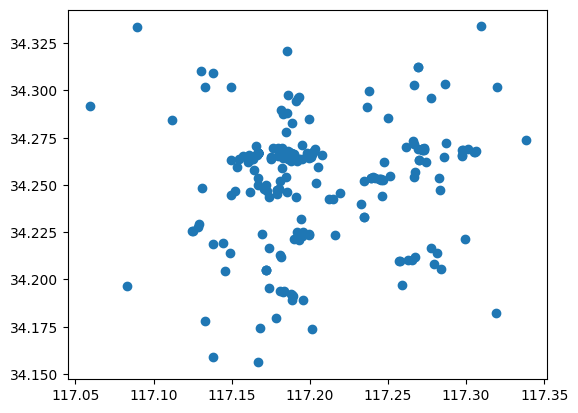

In [ ]:
gdf.plot()

In [ ]:
cities = {
    "beijing": (116.2,39.7,116.6,40.1),
    "shanghai": (121.2,30.9,121.8,31.5),
    "guangzhou": (113.1,22.9,113.6,23.4)
}

for city,bbox in cities.items():

    download_overture_buildings(
        bbox=bbox,
        output=f"{city}.geojson"
    )

为了获得更大的灵活性，`get_overture_data()`直接以GeoDataFrame形式返回数据，并支持多种数据类型（建筑、地点、道路、土地覆盖、水体）：

In [ ]:
gdf = geoai.get_overture_data(
    overture_type="building",
    bbox=(-83.94, 35.96, -83.92, 35.98),
    output="buildings.parquet",
)
print(f"Downloaded {len(gdf)} buildings")
gdf.head()

Overture Maps函数需要`overturemaps`包（`pip install overturemaps`）。

### OpenStreetMap数据

[OpenStreetMap (OSM)](https://www.openstreetmap.org)是由志愿者维护的协作开源地图。[osmnx](https://osmnx.readthedocs.io)和[quackosm](https://kraina-ai.github.io/quackosm)库（使用DuckDB进行快速PBF提取）等库提供了查询OSM数据的Python接口。`leafmap`包包装这些工具以方便访问。

按边界框下载OSM建筑轮廓：

In [ ]:
import leafmap.osm as osm

bbox = (-83.94, 35.96, -83.92, 35.98)  # Knoxville area
buildings = osm.quackosm_gdf_from_bbox(bbox, tags={"building": True})
print(f"Downloaded {len(buildings)} buildings")
buildings.head()

按地点名称查询：

In [ ]:
roads = osm.quackosm_gdf_from_place("Knoxville, Tennessee", tags={"highway": True})
print(f"Downloaded {len(roads)} road segments")
roads.head()

按自定义几何图形查询：

In [ ]:
from shapely.geometry import Polygon

polygon = Polygon(
    [
        (-83.94, 35.96),
        (-83.92, 35.96),
        (-83.92, 35.98),
        (-83.94, 35.98),
    ]
)
natural = osm.quackosm_gdf_from_geometry(polygon, tags={"natural": True})
print(f"Downloaded {len(natural)} natural features")
natural.head()

GeoAI常用的OSM标签包括`building`、`highway`、`landuse`、`natural`、`waterway`和`amenity`。区域的首次下载可能较慢，因为PBF文件需要缓存；后续查询会重用它。

## 组织您的数据

清晰的目录结构可以防止混淆并保持工作流程可重现。推荐的布局：

```text
project/
├── data/
│   ├── raw/              # 原始下载文件（永不修改）
│   │   ├── naip/
│   │   ├── sentinel2/
│   │   ├── landsat/
│   │   └── vectors/
│   ├── processed/        # Clipped, reprojected, or merged files
│   └── training/         # Tiles and labels ready for model training
├── models/               # Saved model weights and configs
├── notebooks/            # Jupyter notebooks for exploration
├── scripts/              # Reusable Python scripts
└── results/              # Predictions, maps, and evaluation outputs
```

遵循以下命名约定：

- **包含来源**：`naip_2021_knoxville.tif`、`s2_20240615_B04.tif`
- **包含日期**：使用ISO格式（YYYY-MM-DD或YYYYMMDD），以便文件按时间顺序排序
- **包含区域**：添加简短的位置标识符，如城市名称或瓦片ID
- **保留原始数据**：永远不要修改原始下载。在单独的目录中创建处理后的副本。
- **使用一致的CRS**：在工作流程早期将所有数据集重投影到公共CRS，以避免后期对齐问题

## 重点要点

1. NAIP提供亚米级美国航空图像，Sentinel-2提供全球10米多光谱数据，Landsat提供超过50年的30米图像。
2. STAC是一个社区规范，标准化了跨多个提供商的地理空间数据搜索。
3. Planetary Computer托管主要卫星集合，可通过`pystac_client`搜索并通过`geoai`下载。
4. `geoai.download_naip()`将NAIP获取简化为单个函数调用。
5. `geoai.download_pc_stac_item()`下载并可选地合并任何Planetary Computer STAC项目的特定波段。
6. Overture Maps和OpenStreetMap提供可通过`geoai`和`leafmap`访问的全球矢量数据。
7. 具有清晰命名约定的组织良好的目录结构使项目可重现。
8. Always inspect downloaded data (CRS, resolution, bands, extent, data type) before proceeding to analysis.